In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

<h3>Inital cleanup of the data</3>

In [2]:
# Loading the dataset
df = pd.read_csv("./data/results.csv")

# Converting the date to datetime eliminating matches before 2000
df["date"] = pd.to_datetime(df["date"])
df = df[df["date"]>="2000-01-01"]

# Dropping null
df.dropna(inplace=True)

# Creating home_advantage column
df["home_advantage"] = (~df["neutral"]).astype(int)

# Dropping unnecessary stuff
df.drop(columns=["city","country","neutral"], inplace=True)

print(df.info())
df.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 25338 entries, 24062 to 49399
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            25338 non-null  datetime64[ns]
 1   home_team       25338 non-null  object        
 2   away_team       25338 non-null  object        
 3   home_score      25338 non-null  float64       
 4   away_score      25338 non-null  float64       
 5   tournament      25338 non-null  object        
 6   home_advantage  25338 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 1.5+ MB
None


,date,home_team,away_team,home_score,away_score,tournament,home_advantage
24062,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,1
24063,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,1
24064,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,1
24065,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,1
24066,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,0
24067,2000-01-09,Ivory Coast,Egypt,2.0,0.0,Friendly,1
24068,2000-01-09,Mexico,Iran,2.0,1.0,Friendly,0
24069,2000-01-11,Bermuda,Canada,0.0,2.0,Friendly,1
24070,2000-01-11,Burkina Faso,Cameroon,2.0,2.0,Friendly,1
24071,2000-01-13,Senegal,Cameroon,0.0,0.0,Friendly,1


<h3>Creating the Elo and recent form system</h3>

<h5>Classifying the tournaments and giving them the weight corresponding to their importance</h5>

In [3]:
# Categories
world_cup = ["FIFA World Cup"]
continental = ["UEFA Euro","Copa América","AFC Asian Cup","African Cup of Nations","Gold Cup","Oceania Nations Cup","ASEAN Championship","EAFF Championship","Arab Cup","CAFA Nations Cup"]
qualifiers = ["FIFA World Cup qualification","UEFA Euro qualification","AFC Asian Cup qualification","African Cup of Nations qualification","CONCACAF Championship qualification","Gold Cup qualification","Oceania Nations Cup qualification","EAFF Championship qualification","ASEAN Championship qualification","CONCACAF Nations League qualification","AFC hallenge Cup qualification","Arab Cup qualification"]
regional = ["UEFA Nations League","CONCACAF Nations League","AFF Championship","SAFF Cup","COSAFA Cup","CECAFA Cup","UNCAF Cup","WAFF Championship","CFU Caribbean Cup"]

# Building the functions
def classify_tournament(tournament):
    if tournament in world_cup:
        return "World Cup"
    elif tournament in continental:
        return "Continental"
    elif tournament in qualifiers:
        return "Qualifier"
    elif tournament in regional:
        return "Regional"
    else:
        return "Other"

def importance(tournament):
    if tournament in world_cup:
        return 5
    elif tournament in continental:
        return 4
    elif tournament in qualifiers:
        return 3
    elif tournament in regional:
        return 2
    else:
        return 1

df["tournament_type"] = df["tournament"].apply(classify_tournament)
df["weight"] = df["tournament"].apply(importance)
df.drop(columns="tournament", inplace=True)
df.head()

,date,home_team,away_team,home_score,away_score,home_advantage,tournament_type,weight
24062,2000-01-04,Egypt,Togo,2.0,1.0,1,Other,1
24063,2000-01-07,Tunisia,Togo,7.0,0.0,1,Other,1
24064,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,1,Other,1
24065,2000-01-09,Burkina Faso,Gabon,1.0,1.0,1,Other,1
24066,2000-01-09,Guatemala,Armenia,1.0,1.0,0,Other,1


<h5>Creating and implementing the Elo and recent form function</h5>

In [4]:
# Creating required list of teams and dict for elo
teams = set(df["home_team"]).union(set(df["away_team"]))
elo = {team: 1500 for team in teams}

# Expected score and elo update function
def expected_score(home,away):
    home_expected = 1/(1+10**((away-home)/400))
    away_expected = 1-home_expected
    return home_expected, away_expected

def update_elo(K, rating, actual, expected):
    return rating + K * (actual - expected)

# Implementing everything
for idx, row in df.iterrows():
    home = row["home_team"]
    away = row["away_team"]

    home_elo = elo[home]
    away_elo = elo[away]

    # Pre-match elos
    df.loc[idx, "home_elo"] = home_elo
    df.loc[idx, "away_elo"] = away_elo

    # Expected values
    home_expected, away_expected = expected_score(home_elo, away_elo)

    # Actual scores
    if row["home_score"] > row["away_score"]:
        home_actual = 1
        away_actual = 0
    elif row["home_score"] < row["away_score"]:
        home_actual = 0
        away_actual = 1
    else:
        home_actual = 0.5
        away_actual = 0.5
    
    K = (row["weight"]*10)

    # Update the scores
    elo[home] = update_elo(K, home_elo, home_actual, home_expected)
    elo[away] = update_elo(K, away_elo, away_actual, away_expected)
df["elo_diff"] = df["home_elo"] - df["away_elo"]
df["elo_gap"] = abs(df["elo_diff"])

In [5]:
df.tail()

,date,home_team,away_team,home_score,away_score,home_advantage,tournament_type,weight,home_elo,away_elo,elo_diff,elo_gap
49395,2026-06-09,Estonia,Lithuania,1.0,0.0,1,Other,1,1344.582143,1291.212037,53.370106,53.370106
49396,2026-06-09,Russia,Trinidad and Tobago,3.0,0.0,1,Other,1,1716.710771,1535.493781,181.216990,181.216990
49397,2026-06-09,Togo,Benin,5.0,1.0,1,Other,1,1454.441539,1515.967147,-61.525608,61.525608
49398,2026-06-09,Liberia,Sierra Leone,3.0,1.0,1,Other,1,1425.392606,1464.271281,-38.878675,38.878675
49399,2026-06-09,Iraq,Venezuela,0.0,2.0,0,Other,1,1704.707795,1658.710661,45.997134,45.997134


<h3>Filtering dataset to only contain the matches of WC teams</h3>

In [6]:
wc_teams = ['Algeria', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Brazil', 'Bosnia and Herzegovina', 'Canada', 'Cape Verde', 'Colombia', 'Croatia', 'Curaçao', 'Czech Republic', 'DR Congo', 'Ecuador', 'Egypt', 'England', 'France', 'Germany', 'Ghana', 'Haiti', 'Iran', 'Iraq', 'Ivory Coast', 'Japan', 'Jordan', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Norway', 'Panama', 'Paraguay', 'Portugal', 'Qatar', 'Saudi Arabia', 'Scotland', 'Senegal', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Tunisia', 'Turkey', 'United States', 'Uruguay', 'Uzbekistan']

df = df[(df["home_team"].isin(wc_teams)) | (df["away_team"].isin(wc_teams))]

# Arranging the matches chronologically
df = df.sort_values("date").reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12077 entries, 0 to 12076
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             12077 non-null  datetime64[ns]
 1   home_team        12077 non-null  object        
 2   away_team        12077 non-null  object        
 3   home_score       12077 non-null  float64       
 4   away_score       12077 non-null  float64       
 5   home_advantage   12077 non-null  int64         
 6   tournament_type  12077 non-null  object        
 7   weight           12077 non-null  int64         
 8   home_elo         12077 non-null  float64       
 9   away_elo         12077 non-null  float64       
 10  elo_diff         12077 non-null  float64       
 11  elo_gap          12077 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(2), object(3)
memory usage: 1.1+ MB


<h3>Calculating recent form</h3>

In [7]:
def recent_form(country, matchdate):
    form = 0
    recent_matches = df[((df["home_team"] == country) | (df["away_team"] == country)) & (df["date"] < matchdate)].tail()
    for _, row in recent_matches.iterrows():
        if row["home_score"] == row["away_score"]:
            form += 1
        elif row["home_score"] > row["away_score"] and row["home_team"] == country:
            form += 3
        elif row["home_score"] < row["away_score"] and row["away_team"] == country:
            form += 3
        else:
            form += 0
    return form

for idx2, row2 in df.iterrows():
    home_form = recent_form(row2["home_team"], row2["date"])
    away_form = recent_form(row2["away_team"], row2["date"])

    df.loc[idx2, "home_form"] = home_form
    df.loc[idx2, "away_form"] = away_form


In [8]:
df["form_diff"] = df["home_form"] - df["away_form"]
df.tail()

,date,home_team,away_team,home_score,away_score,home_advantage,tournament_type,weight,home_elo,away_elo,elo_diff,elo_gap,home_form,away_form,form_diff
12072,2026-06-08,France,Northern Ireland,3.0,1.0,1,Other,1,1920.924587,1506.330887,414.593701,414.593701,12.0,1.0,11.0
12073,2026-06-09,DR Congo,Chile,1.0,2.0,0,Other,1,1678.572725,1628.375092,50.197633,50.197633,10.0,4.0,6.0
12074,2026-06-09,Saudi Arabia,Senegal,0.0,0.0,0,Other,1,1666.063078,1813.530995,-147.467917,147.467917,3.0,9.0,-6.0
12075,2026-06-09,Argentina,Iceland,3.0,0.0,0,Other,1,1953.598421,1509.299439,444.298981,444.298981,15.0,3.0,12.0
12076,2026-06-09,Iraq,Venezuela,0.0,2.0,0,Other,1,1704.707795,1658.710661,45.997134,45.997134,7.0,4.0,3.0


<h3>Goal difference for the last 5 matches</h3>

In [9]:
def goal_diff(country, matchdate):
    gd = 0
    recent_matches = df[((df["home_team"] == country) | (df["away_team"] == country)) & (df["date"] < matchdate)].tail()
    for _, row in recent_matches.iterrows():
        if row["home_team"] == country:
            gd += row["home_score"] - row["away_score"]
        else:
            gd += row["away_score"] - row["home_score"]
    return gd

for idx3, row3 in df.iterrows():
    home_gd = goal_diff(row3["home_team"], row3["date"])
    away_gd = goal_diff(row3["away_team"], row3["date"])

    df.loc[idx3, "home_gd"] = home_gd
    df.loc[idx3, "away_gd"] = away_gd

In [10]:
df["gd_diff"] = df["home_gd"] - df["away_gd"]
df.tail()

,date,home_team,away_team,home_score,away_score,home_advantage,tournament_type,weight,home_elo,away_elo,elo_diff,elo_gap,home_form,away_form,form_diff,home_gd,away_gd,gd_diff
12072,2026-06-08,France,Northern Ireland,3.0,1.0,1,Other,1,1920.924587,1506.330887,414.593701,414.593701,12.0,1.0,11.0,8.0,-11.0,19.0
12073,2026-06-09,DR Congo,Chile,1.0,2.0,0,Other,1,1678.572725,1628.375092,50.197633,50.197633,10.0,4.0,6.0,5.0,-5.0,10.0
12074,2026-06-09,Saudi Arabia,Senegal,0.0,0.0,0,Other,1,1666.063078,1813.530995,-147.467917,147.467917,3.0,9.0,-6.0,-4.0,1.0,-5.0
12075,2026-06-09,Argentina,Iceland,3.0,0.0,0,Other,1,1953.598421,1509.299439,444.298981,444.298981,15.0,3.0,12.0,16.0,-5.0,21.0
12076,2026-06-09,Iraq,Venezuela,0.0,2.0,0,Other,1,1704.707795,1658.710661,45.997134,45.997134,7.0,4.0,3.0,-1.0,-3.0,2.0


<h3>Adding the target column</h3>

In [11]:
def result(row):
    if row["home_score"] > row["away_score"]:
        return 2 # home win
    elif row["home_score"] == row["away_score"]:
        return 1 # draw
    else:
        return 0 # home loss
df["result"] = df.apply(result, axis=1)

df.tail()

,date,home_team,away_team,home_score,away_score,home_advantage,tournament_type,weight,home_elo,away_elo,elo_diff,elo_gap,home_form,away_form,form_diff,home_gd,away_gd,gd_diff,result
12072,2026-06-08,France,Northern Ireland,3.0,1.0,1,Other,1,1920.924587,1506.330887,414.593701,414.593701,12.0,1.0,11.0,8.0,-11.0,19.0,2
12073,2026-06-09,DR Congo,Chile,1.0,2.0,0,Other,1,1678.572725,1628.375092,50.197633,50.197633,10.0,4.0,6.0,5.0,-5.0,10.0,0
12074,2026-06-09,Saudi Arabia,Senegal,0.0,0.0,0,Other,1,1666.063078,1813.530995,-147.467917,147.467917,3.0,9.0,-6.0,-4.0,1.0,-5.0,1
12075,2026-06-09,Argentina,Iceland,3.0,0.0,0,Other,1,1953.598421,1509.299439,444.298981,444.298981,15.0,3.0,12.0,16.0,-5.0,21.0,2
12076,2026-06-09,Iraq,Venezuela,0.0,2.0,0,Other,1,1704.707795,1658.710661,45.997134,45.997134,7.0,4.0,3.0,-1.0,-3.0,2.0,0


<h3>Building and training the model</h3>

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

features = ["elo_diff", "elo_gap", "form_diff","weight","gd_diff","home_advantage"]


# Splitting the dataset
#x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
train = df[df["date"]<"2021-01-01"]
test = df[df["date"]>="2021-01-01"]

x_test = test[features]
y_test = test["result"]

x_train = train[features]   
y_train = train["result"]

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Model
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
preds = model.predict(x_test)
accuracy_score(y_test, preds)


0.6121372031662269

In [14]:
print(confusion_matrix(y_test, preds))
df["result"].value_counts(normalize=False)

[[510 111 114]
 [222 145 243]
 [159 180 969]]


result
2    5785
0    3405
1    2887
Name: count, dtype: int64

In [15]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.57      0.69      0.63       735
           1       0.33      0.24      0.28       610
           2       0.73      0.74      0.74      1308

    accuracy                           0.61      2653
   macro avg       0.55      0.56      0.55      2653
weighted avg       0.60      0.61      0.60      2653



<h3>Saving the snapshots of Elo, form and gd</h3>

<h5>Also writing functions to create lists with recent gd and form</h5>

In [16]:
import copy

# Computing current elo, form and gd
final_elo = {team : elo[team] for team in wc_teams}

def get_intial_form(team):
    recent = df[((df["home_team"] == team) | (df["away_team"] == team))].tail()
    points = []
    for _, row in recent.iterrows():
        if row["home_score"] == row["away_score"]:
            points.append(1)
        elif row["home_score"] > row["away_score"] and row["home_team"] == team:
            points.append(3)
        elif row["home_score"] < row["away_score"] and row["away_team"] == team:
            points.append(3)
        else:
            points.append(0)
    return points

def get_initial_gd(team):
    recent = df[((df["home_team"] == team) | (df["away_team"] == team))].tail()
    gd_list = []
    for _, row in recent.iterrows():
        if row["home_team"] == team:
            gd_list.append(row["home_score"] - row["away_score"])
        else:
            gd_list.append(row["away_score"] - row["home_score"])
    return gd_list

current_gd = {team : get_initial_gd(team) for team in wc_teams}
current_form = {team : get_intial_form(team) for team in wc_teams}

# Creating snapshots to reset to after every simulation
elo_snapshot = copy.deepcopy(final_elo)
gd_snapshot = copy.deepcopy(current_gd)
form_snapshot = copy.deepcopy(current_form)

<h3>Simulating the tournament</h3>

In [17]:
# These will be modified during the simulation
simulated_form = copy.deepcopy(current_form)
simulated_gd = copy.deepcopy(current_gd)

<h5>Predicting a single match</h5>

In [18]:
def predict_match(home, away):
    #features = ["elo_diff", "elo_gap", "form_diff","weight","gd_diff","home_advantage"]
    conditions = {"elo_diff" : final_elo[home]-final_elo[away],
            "elo_gap" : abs(final_elo[home]-final_elo[away]),
            "form_diff" : sum(simulated_form[home])-sum(simulated_form[away]),
            "weight" : 5, # Since WC matches
            "gd_diff" : sum(simulated_gd[home])-sum(simulated_gd[away]),
            "home_advantage" : 0 # Since WC
            }
    x = scaler.transform(pd.DataFrame([conditions]))
    prob = model.predict_proba(x)[0]
    return {"home_win" : prob[2], "draw" : prob[1], "away_win" : prob[0]}

<h5>Predicting the score of a match</h5>

In [19]:
def score_simulator(home, away, outcome):
    rng = np.random.default_rng()
    elo_diff = final_elo[home] - final_elo[away]

    # Setting up the parameters
    home_lambda = df["home_score"].mean() + (elo_diff/2000)
    away_lambda = df["away_score"].mean() - (elo_diff/2000)
    home_lambda = max(0.3, home_lambda)
    away_lambda = max(0.3, away_lambda)  # To avoid near zero situations

    # Generating score line to match the outcome
    while True:
        home_score = rng.poisson(home_lambda)
        away_score = rng.poisson(away_lambda)
        if (home_score > away_score and outcome == "home_win") or (home_score < away_score and outcome == "away_win") or (home_score == away_score and outcome == "draw"):
            return home_score, away_score

<h5>Updating the ELO, form and gd</h5>

In [20]:
# For ELO
def update_simulated_elo(home, away, outcome):
    if outcome == "home_win":
        home_actual = 1
    elif outcome == "away_win":
        home_actual = 0
    else:
        home_actual = 0.5
    away_actual = 1 - home_actual
    K = 5*20

    final_elo[home] = update_elo(K, final_elo[home], home_actual, home_expected)
    final_elo[away] = update_elo(K, final_elo[away], away_actual, away_expected)

# For form
def update_simulated_form(home, away, outcome):
    if outcome == "home_win":
        simulated_form[home].append(3)
        simulated_form[away].append(0)
    elif outcome == "away_win":
        simulated_form[away].append(3)
        simulated_form[home].append(0)
    else:
        simulated_form[home].append(1)
        simulated_form[away].append(1)
    simulated_form[home] = simulated_form[home][-5:]
    simulated_form[away] = simulated_form[away][-5:]

# For gd
def update_simulated_gd(home, away, home_score, away_score):
    simulated_gd[home].append(home_score - away_score)
    simulated_gd[away].append(away_score - home_score)

    simulated_gd[home] = simulated_gd[home][-5:]
    simulated_gd[away] = simulated_gd[away][-5:]

<h5>Simulating Group stage</h5>

In [21]:
# To simulate matches of a single group
def simulate_group(group):
    standings = {team : {"points" : 0, "gf" : 0, "ga" : 0} for team in wc_teams}

    # Round-Robin format
    for i in range(len(group)):
        for j in range(i+1, len(group)):
            home, away = group[i], group[j]
            result = predict_match(home, away) # Returns a dict with the probabilities
            # Choosing the outcome
            outcome = random.choices(["home_win", "draw", "away_win"], weights = [result["home_win"], result["draw"], result["away_win"]])[0]
            # Predicting the scoreline
            home_score, away_score = score_simulator(home, away, outcome)

            # Updating the standings
            standings[home]["gf"] += home_score
            standings[home]["ga"] += away_score
            standings[away]["gf"] += away_score
            standings[away]["ga"] += home_score
            if outcome == "home_win":
                standings[home]["points"] += 3
            elif outcome == "draw":
                standings[home]["points"] += 1
                standings[away]["points"] += 1
            else:
                standings[away]["points"] += 3
            
            # Updating the ELO, form and gd
            update_simulated_elo(home, away, outcome)
            update_simulated_form(home, away, outcome)
            update_simulated_gd(home, away, home_score, away_score)
    return standings

# To rank the group
def rank_group(standings):
    return sorted(standings.keys(), key = lambda t: (standings[t]["points"], standings[t]["gf"] - standings[t]["ga"], standings[t]["gf"]), reverse=True)


<h5>Defining the groups</h5>

In [22]:
groups = {
    "A" : ["Mexico", "South Africa", "South Korea", "Czech Republic"],
    "B" : ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"] ,
    "C" : ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D" : ["United States", "Paraguay", "Australia", "Turkey"],
    "E" : ["Germany", "Curaçao", "Ivory Coast", "Ecuador"],
    "F" : ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G" : ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H" : ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I" : ["France", "Senegal", "Iraq", "Norway"],
    "J" : ["Argentina", "Algeria", "Austria", "Jordan"],
    "K" : ["Portugal", "DR Congo", "Uzbekistan", "Colombia"],
    "L" : ["England", "Croatia", "Ghana", "Panama"]
}

<h5>Running all the groups and finding the qualified teams</h5>

In [23]:
def simulate_group_stage(groups):
    group_results = {}
    all_third_place = []

    for name, group in groups.items():
        standings = simulate_group(group)
        ranked = rank_group(standings)
        group_results[name] = {"ranked" : ranked, "standings" : standings}
        # Top 2 and 8 best 3rd teams qualify for Ro32
        third = ranked[2]
        all_third_place.append((third, standings[third]))

    # Picking the 8 best teams for Ro32
    best_thirds = sorted(all_third_place, key = lambda x: (x[1]["points"], x[1]["gf"] - x[1]["ga"], x[1]["gf"]), reverse=True)[:8]
    best_third_teams = [t[0] for t in best_thirds]
    return group_results, best_third_teams


In [24]:
def knockout_winner(team_a, team_b):
    result = predict_match(team_a, team_b)

    # Eliminating draw
    total = result["home_win"] + result["away_win"]
    p_a = result["home_win"]/total

    if random.random() < p_a:
        outcome = "home_win"
    else:
        outcome = "away_win"
    a_score, b_score = score_simulator(team_a, team_b, outcome)

    # Updating
    update_simulated_elo(team_a, team_b, outcome)
    update_simulated_form(team_a, team_b, outcome)
    update_simulated_gd(team_a, team_b, a_score, b_score)

    if outcome == "home_win":
        return team_a
    else:
        return team_b

In [25]:
def simulate_knockout_stage(group_results, best_third_teams):
    group_winners  = {g: group_results[g]["ranked"][0] for g in group_results}
    group_runners = {g: group_results[g]["ranked"][1] for g in group_results}
    # Sorting 3rd place teams by ELO for the bracket
    thirds = sorted(best_third_teams, key=lambda t: final_elo[t], reverse=True)
    # Round of 32 bracket
    ro32 = [
        (group_winners["A"],  group_runners["B"]),   (group_winners["C"],  thirds[0]),
        (group_winners["B"],  thirds[1]), (group_winners["D"],  group_runners["E"]),
        (group_winners["E"],  group_runners["F"]),   (group_winners["F"],  thirds[2]),
        (group_winners["G"],  group_runners["H"]),   (group_winners["H"],  thirds[3]),
        (group_winners["I"],  group_runners["J"]),   (group_winners["J"],  thirds[4]),
        (group_winners["K"],  group_runners["L"]),   (group_winners["L"],  thirds[5]),
        (group_runners["A"], group_runners["C"]),   (group_runners["D"], thirds[6]),
        (group_runners["G"], group_runners["I"]),   (group_runners["K"], thirds[7]),
    ]

    # Simulating the round
    def simulate_round(matchups):
        winners = []
        for a, b in matchups:
            w = knockout_winner(a, b)
            winners.append(w)
        return winners

    r16      = simulate_round(ro32)
    qf       = simulate_round(list(zip(r16[::2], r16[1::2])))
    sf       = simulate_round(list(zip(qf[::2],  qf[1::2])))
    finalists = simulate_round(list(zip(sf[::2], sf[1::2])))

    champion = knockout_winner(finalists[0], finalists[1])
    

    return champion

In [29]:
from collections import defaultdict

tournament_wins = defaultdict(int)
N = 10000

for _ in range(N):
    # Resetting the parameters after every run
    final_elo      = copy.deepcopy(elo_snapshot)
    simulated_form = copy.deepcopy(form_snapshot)
    simulated_gd   = copy.deepcopy(gd_snapshot)
    group_results, best_third_teams = simulate_group_stage(groups)
    winner = simulate_knockout_stage(group_results, best_third_teams)
    tournament_wins[winner] += 1

<h3>Win probabilities of various nations</h3>

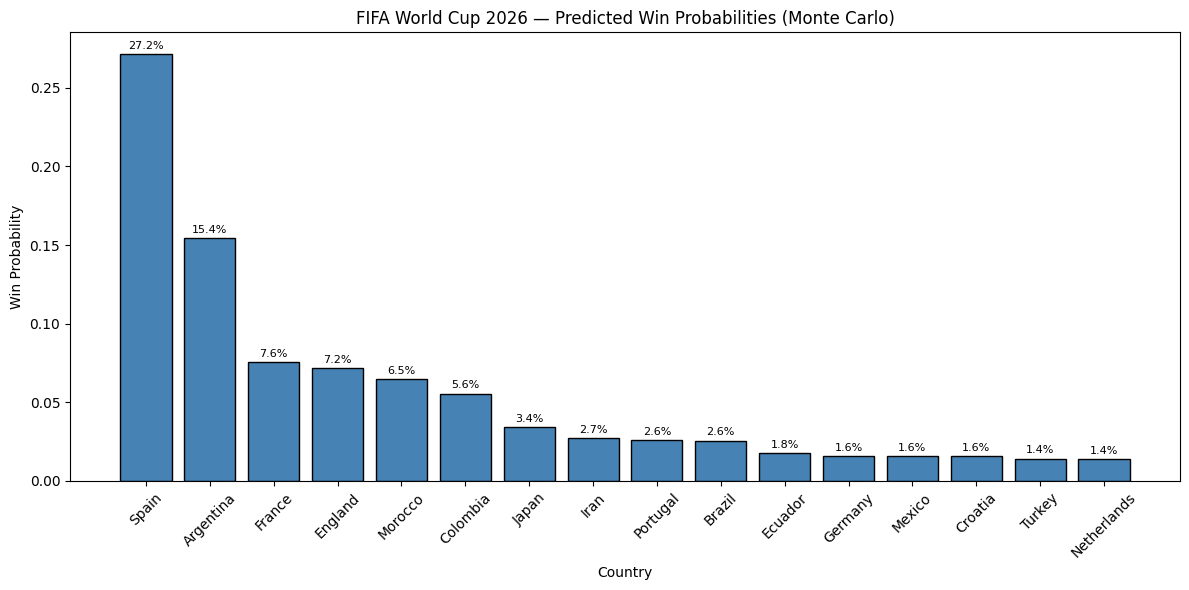

In [30]:
top_teams = sorted(tournament_wins.items(), key=lambda x: -x[1])[:16]
teams_list, counts = zip(*top_teams)
probs = [c/N for c in counts]

plt.figure(figsize=(12, 6))
bars = plt.bar(teams_list, probs, color="steelblue", edgecolor="black")
plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Win Probability")
plt.title("FIFA World Cup 2026 — Predicted Win Probabilities (Monte Carlo)")
plt.tight_layout()

# Add percentage labels on bars
for bar, prob in zip(bars, probs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{prob:.1%}", ha="center", va="bottom", fontsize=8)

plt.show()

<h3>Saving required data for the app</h3>

In [31]:
import joblib
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(elo_snapshot, "elo.pkl")
joblib.dump(form_snapshot, "form.pkl")
joblib.dump(gd_snapshot, "gd.pkl")

['gd.pkl']

In [35]:
for i in range(10):
    print(f"{teams_list[i]} - {probs[i]:.2%}")

Spain - 27.16%
Argentina - 15.45%
France - 7.56%
England - 7.16%
Morocco - 6.47%
Colombia - 5.56%
Japan - 3.41%
Iran - 2.71%
Portugal - 2.62%
Brazil - 2.57%
